# 🛒 E-Commerce Sales Analysis & Revenue Prediction

**Objective:** Perform comprehensive exploratory data analysis on e-commerce sales data and build a machine learning model to predict order revenue.

**Dataset:** 5,000 e-commerce transactions with features like product category, region, quantity, unit price, discount, payment method, delivery days, and customer ratings.

---

## 1. 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully! ✅')

All libraries imported successfully! ✅


## 2. 📂 Load & Explore Data

In [2]:
# Load dataset
df = pd.read_csv('ecommerce_sales_analytics_5000.csv')
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head()

Dataset Shape: 5000 rows × 12 columns
Memory Usage: 593.2 KB


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [3]:
# Data types and info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 593.2 KB


In [4]:
# Statistical summary
df.describe().round(2)

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,12500.50,1505.70,4.04,308.42,0.18,6.12,2.97,1021.96
std,1443.52,290.84,2.02,169.26,0.10,3.15,1.16,825.58
min,10001.00,1000.00,1.00,15.15,0.00,1.00,1.00,11.21
25%,11250.75,1253.00,2.00,161.90,0.09,3.00,2.00,354.53
50%,12500.50,1510.00,4.00,309.89,0.18,6.00,3.00,796.65
75%,13750.25,1761.00,6.00,455.56,0.27,9.00,4.00,1515.69
max,15000.00,1999.00,7.00,599.96,0.35,11.00,5.00,4119.33


In [5]:
# Check for missing values
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found! ✅')
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing Values:
No missing values found! ✅

Duplicate rows: 0


In [6]:
# Unique values per column
print('Unique values per column:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} unique values')
    if df[col].dtype == 'object':
        print(f'    Values: {df[col].unique()}')

Unique values per column:
  order_id: 5000 unique values
  order_date: 5000 unique values
  customer_id: 989 unique values
  product_category: 4 unique values
  region: 4 unique values
  quantity: 7 unique values
  unit_price: 4788 unique values
  discount: 36 unique values
  payment_method: 3 unique values
  delivery_days: 11 unique values
  customer_rating: 41 unique values
  revenue: 4940 unique values


## 3. 🔧 Data Cleaning & Feature Engineering

In [7]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')

# Extract time-based features
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day_of_week'] = df['order_date'].dt.dayofweek
df['order_quarter'] = df['order_date'].dt.quarter

# Create derived features
df['total_before_discount'] = df['quantity'] * df['unit_price']
df['discount_amount'] = df['total_before_discount'] * df['discount']
df['price_per_unit_after_discount'] = df['unit_price'] * (1 - df['discount'])

print('✅ Feature engineering complete!')
print(f'New shape: {df.shape}')
df.head()

✅ Feature engineering complete!
New shape: (5000, 19)


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order_year,order_month,order_day_of_week,order_quarter,total_before_discount,discount_amount,price_per_unit_after_discount
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,5,1,2615.55,732.3540,269.0280
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,6,1,334.18,30.0762,43.4434
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,0,1,933.84,289.4904,214.7832
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,1,1,2622.35,52.4470,513.9806
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,2,1,699.35,230.7855,93.7129


## 4. 📊 Exploratory Data Analysis (EDA)

### 4.1 Revenue Distribution

Revenue Statistics:
  Mean:   $1,021.96
  Median: $796.65
  Std:    $825.58
  Min:    $11.21
  Max:    $4,119.33
  Skew:   1.002


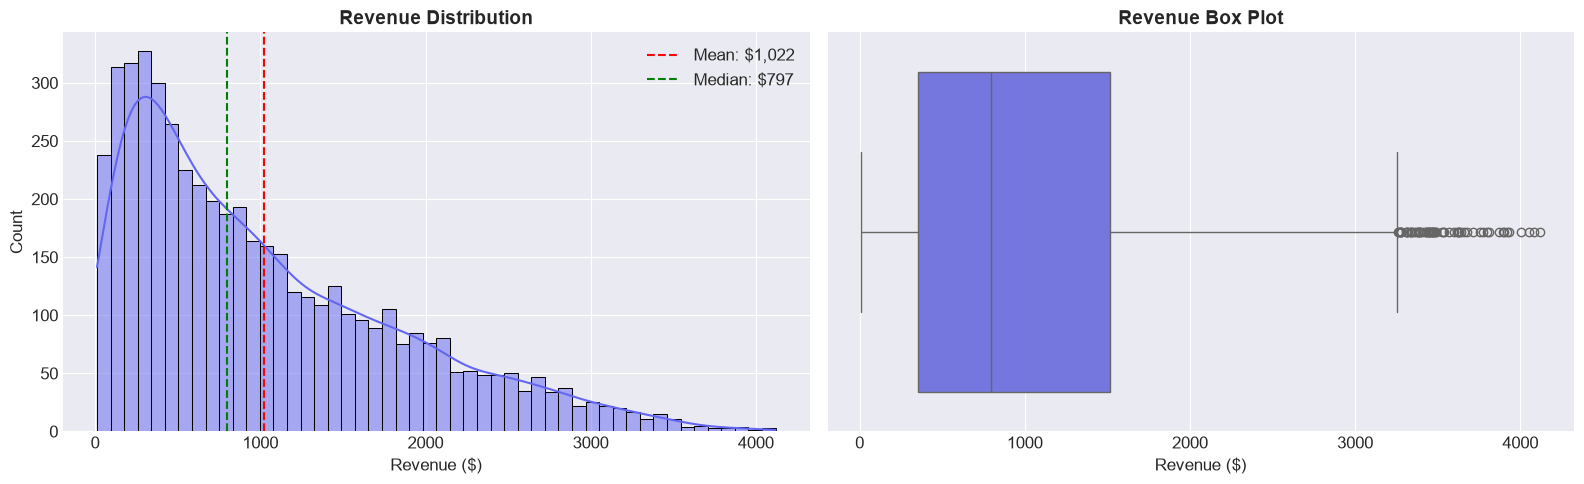

In [8]:
print('Revenue Statistics:')
print(f'  Mean:   ${df["revenue"].mean():,.2f}')
print(f'  Median: ${df["revenue"].median():,.2f}')
print(f'  Std:    ${df["revenue"].std():,.2f}')
print(f'  Min:    ${df["revenue"].min():,.2f}')
print(f'  Max:    ${df["revenue"].max():,.2f}')
print(f'  Skew:   {df["revenue"].skew():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(df['revenue'], bins=50, kde=True, color='#6366f1', ax=axes[0])
axes[0].set_title('Revenue Distribution', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Revenue ($)')
axes[0].axvline(df['revenue'].mean(), color='red', linestyle='--', label=f'Mean: ${df["revenue"].mean():,.0f}')
axes[0].axvline(df['revenue'].median(), color='green', linestyle='--', label=f'Median: ${df["revenue"].median():,.0f}')
axes[0].legend()

# Box plot
sns.boxplot(x=df['revenue'], color='#6366f1', ax=axes[1])
axes[1].set_title('Revenue Box Plot', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Revenue ($)')

plt.tight_layout()
plt.show()

### 4.2 Revenue by Product Category

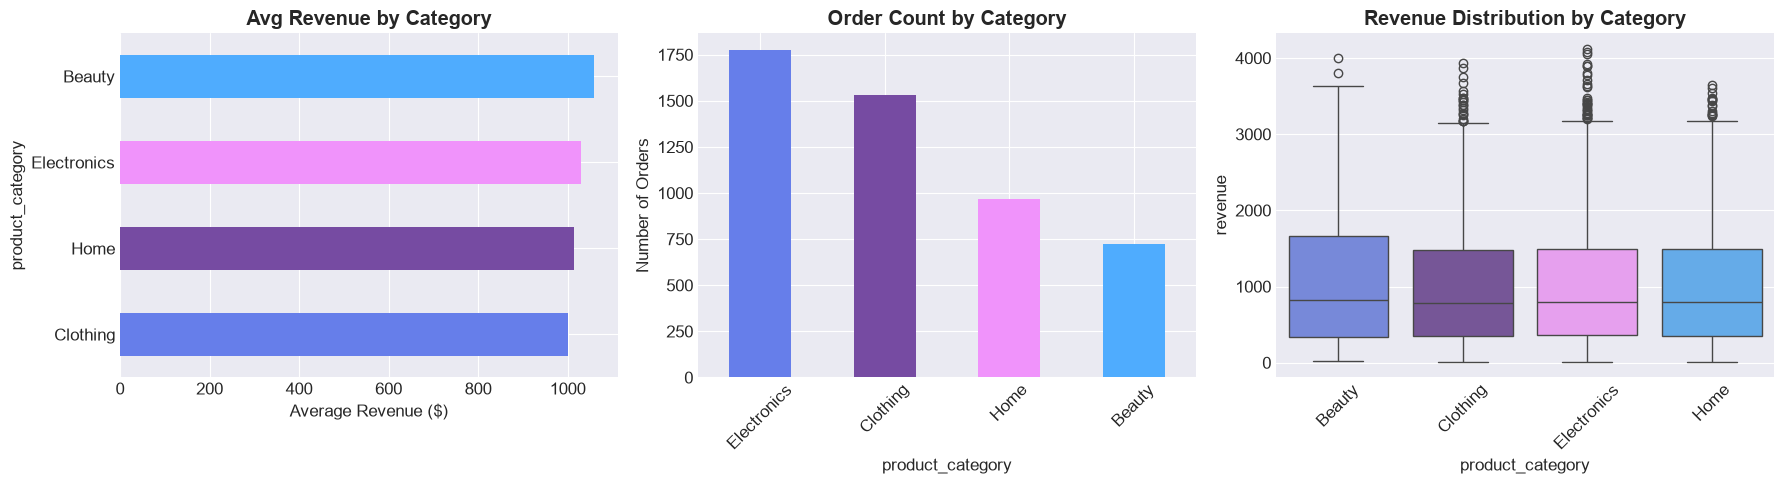


Category-wise Statistics:


,total_orders,total_revenue,avg_revenue,avg_rating,avg_discount
product_category,,,,,
Beauty,723,765860.88,1059.28,3.01,0.18
Clothing,1531,1531931.72,1000.61,3.01,0.18
Electronics,1777,1829899.22,1029.77,2.95,0.18
Home,969,982083.92,1013.50,2.94,0.18


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#667eea', '#764ba2', '#f093fb', '#4facfe']

# Average revenue by category
cat_rev = df.groupby('product_category')['revenue'].mean().sort_values(ascending=True)
cat_rev.plot(kind='barh', color=colors, ax=axes[0])
axes[0].set_title('Avg Revenue by Category', fontweight='bold')
axes[0].set_xlabel('Average Revenue ($)')

# Total orders by category
cat_count = df['product_category'].value_counts()
cat_count.plot(kind='bar', color=colors, ax=axes[1])
axes[1].set_title('Order Count by Category', fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

# Revenue distribution by category
sns.boxplot(data=df, x='product_category', y='revenue', palette=colors, ax=axes[2])
axes[2].set_title('Revenue Distribution by Category', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Detailed stats
print('\nCategory-wise Statistics:')
cat_stats = df.groupby('product_category').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('revenue', 'sum'),
    avg_revenue=('revenue', 'mean'),
    avg_rating=('customer_rating', 'mean'),
    avg_discount=('discount', 'mean')
).round(2)
cat_stats

### 4.3 Revenue by Region

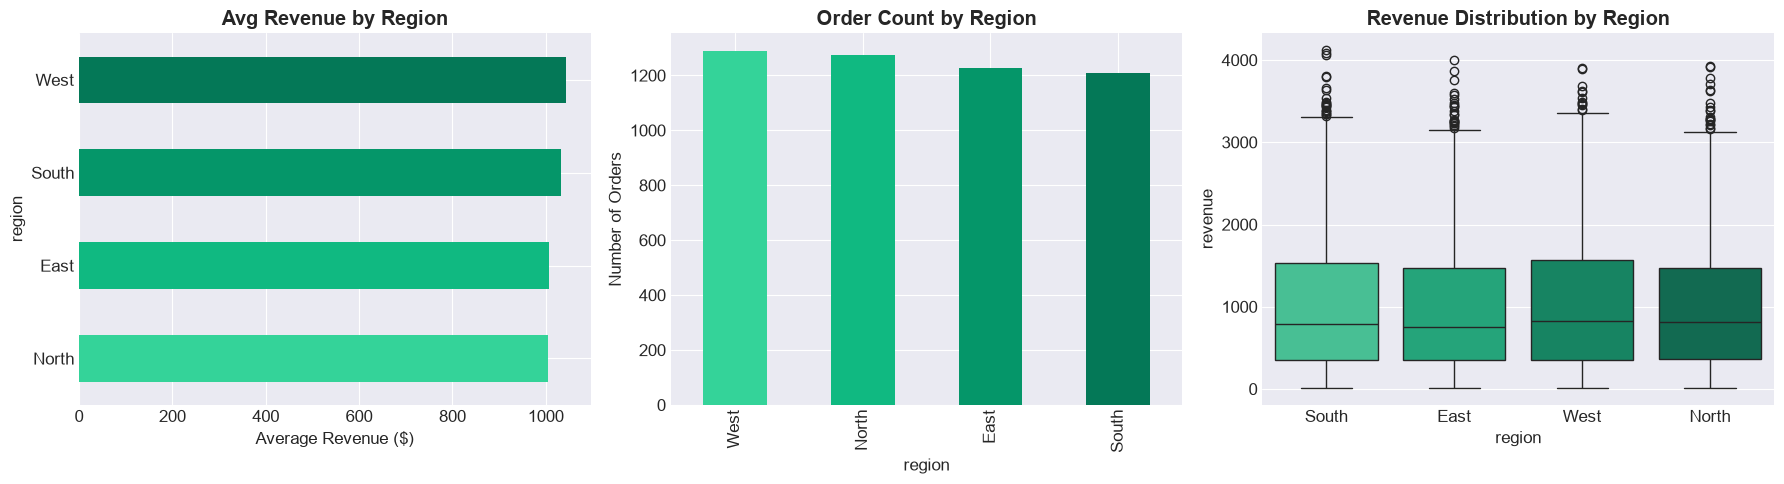


Region-wise Statistics:


,total_orders,total_revenue,avg_revenue,avg_discount
region,,,,
East,1227,1236044.23,1007.37,0.18
North,1276,1281508.45,1004.32,0.18
South,1208,1246640.90,1031.99,0.18
West,1289,1345582.16,1043.90,0.18


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
region_colors = ['#34d399', '#10b981', '#059669', '#047857']

# Average revenue by region
region_rev = df.groupby('region')['revenue'].mean().sort_values(ascending=True)
region_rev.plot(kind='barh', color=region_colors, ax=axes[0])
axes[0].set_title('Avg Revenue by Region', fontweight='bold')
axes[0].set_xlabel('Average Revenue ($)')

# Total orders by region
region_count = df['region'].value_counts()
region_count.plot(kind='bar', color=region_colors, ax=axes[1])
axes[1].set_title('Order Count by Region', fontweight='bold')
axes[1].set_ylabel('Number of Orders')

# Revenue distribution by region
sns.boxplot(data=df, x='region', y='revenue', palette=region_colors, ax=axes[2])
axes[2].set_title('Revenue Distribution by Region', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nRegion-wise Statistics:')
region_stats = df.groupby('region').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('revenue', 'sum'),
    avg_revenue=('revenue', 'mean'),
    avg_discount=('discount', 'mean')
).round(2)
region_stats

### 4.4 Payment Method Analysis

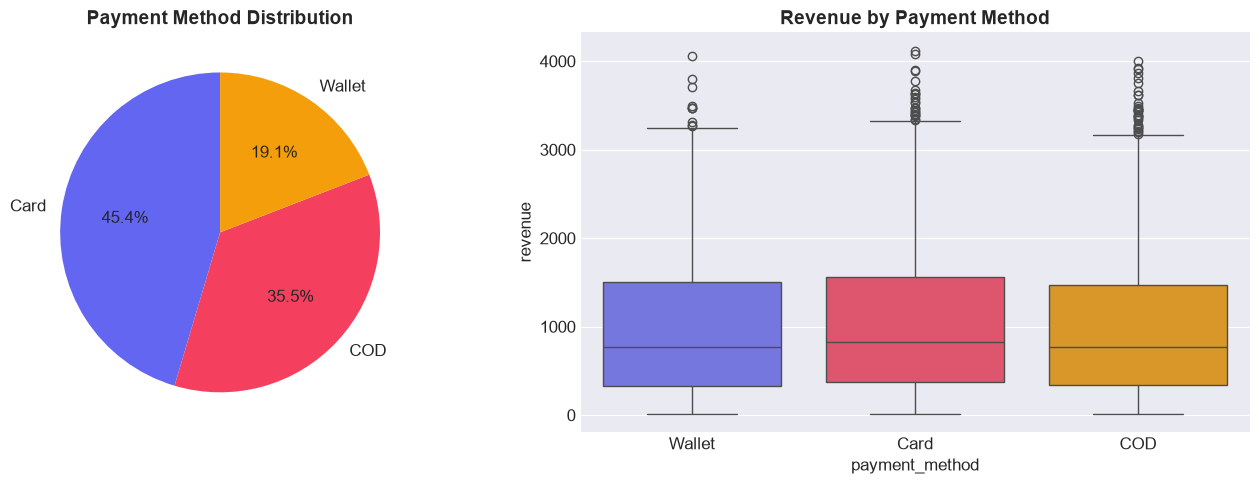

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
payment_colors = ['#6366f1', '#f43f5e', '#f59e0b']

# Pie chart
payment_counts = df['payment_method'].value_counts()
axes[0].pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%',
            colors=payment_colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Payment Method Distribution', fontweight='bold', fontsize=14)

# Revenue by payment method
sns.boxplot(data=df, x='payment_method', y='revenue', palette=payment_colors, ax=axes[1])
axes[1].set_title('Revenue by Payment Method', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

### 4.5 Correlation Analysis

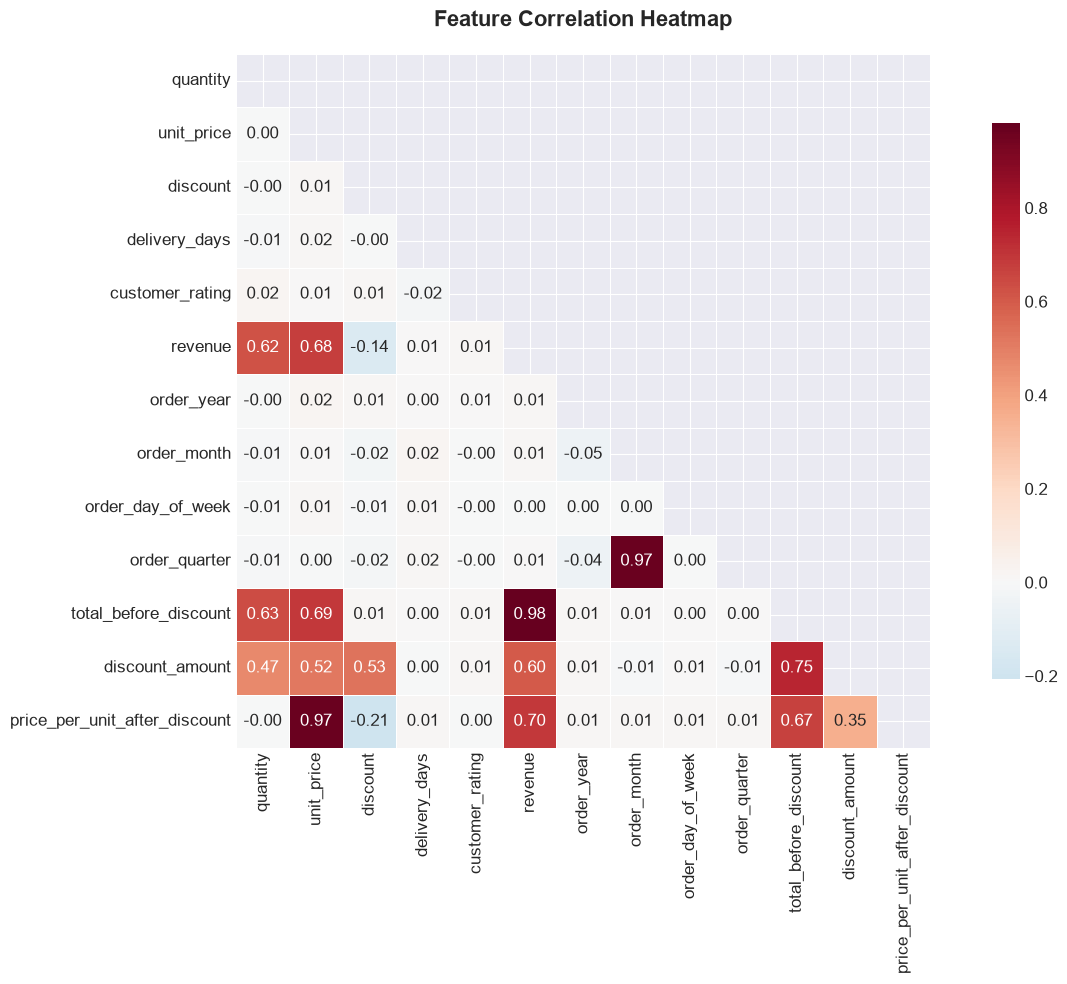


Top Correlations with Revenue:
  + total_before_discount: 0.981
  + price_per_unit_after_discount: 0.698
  + unit_price: 0.678
  + quantity: 0.624
  + discount_amount: 0.600
  - discount: -0.139
  + customer_rating: 0.012
  + order_year: 0.009
  + order_month: 0.008
  + order_quarter: 0.006
  + delivery_days: 0.005
  + order_day_of_week: 0.002


In [12]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_cols = [c for c in numeric_cols if c not in ['order_id', 'customer_id']]
correlation_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with revenue
print('\nTop Correlations with Revenue:')
revenue_corr = correlation_matrix['revenue'].drop('revenue').abs().sort_values(ascending=False)
for feat, corr_val in revenue_corr.items():
    direction = '+' if correlation_matrix.loc[feat, 'revenue'] > 0 else '-'
    print(f'  {direction} {feat}: {correlation_matrix.loc[feat, "revenue"]:.3f}')

### 4.6 Key Relationships with Revenue

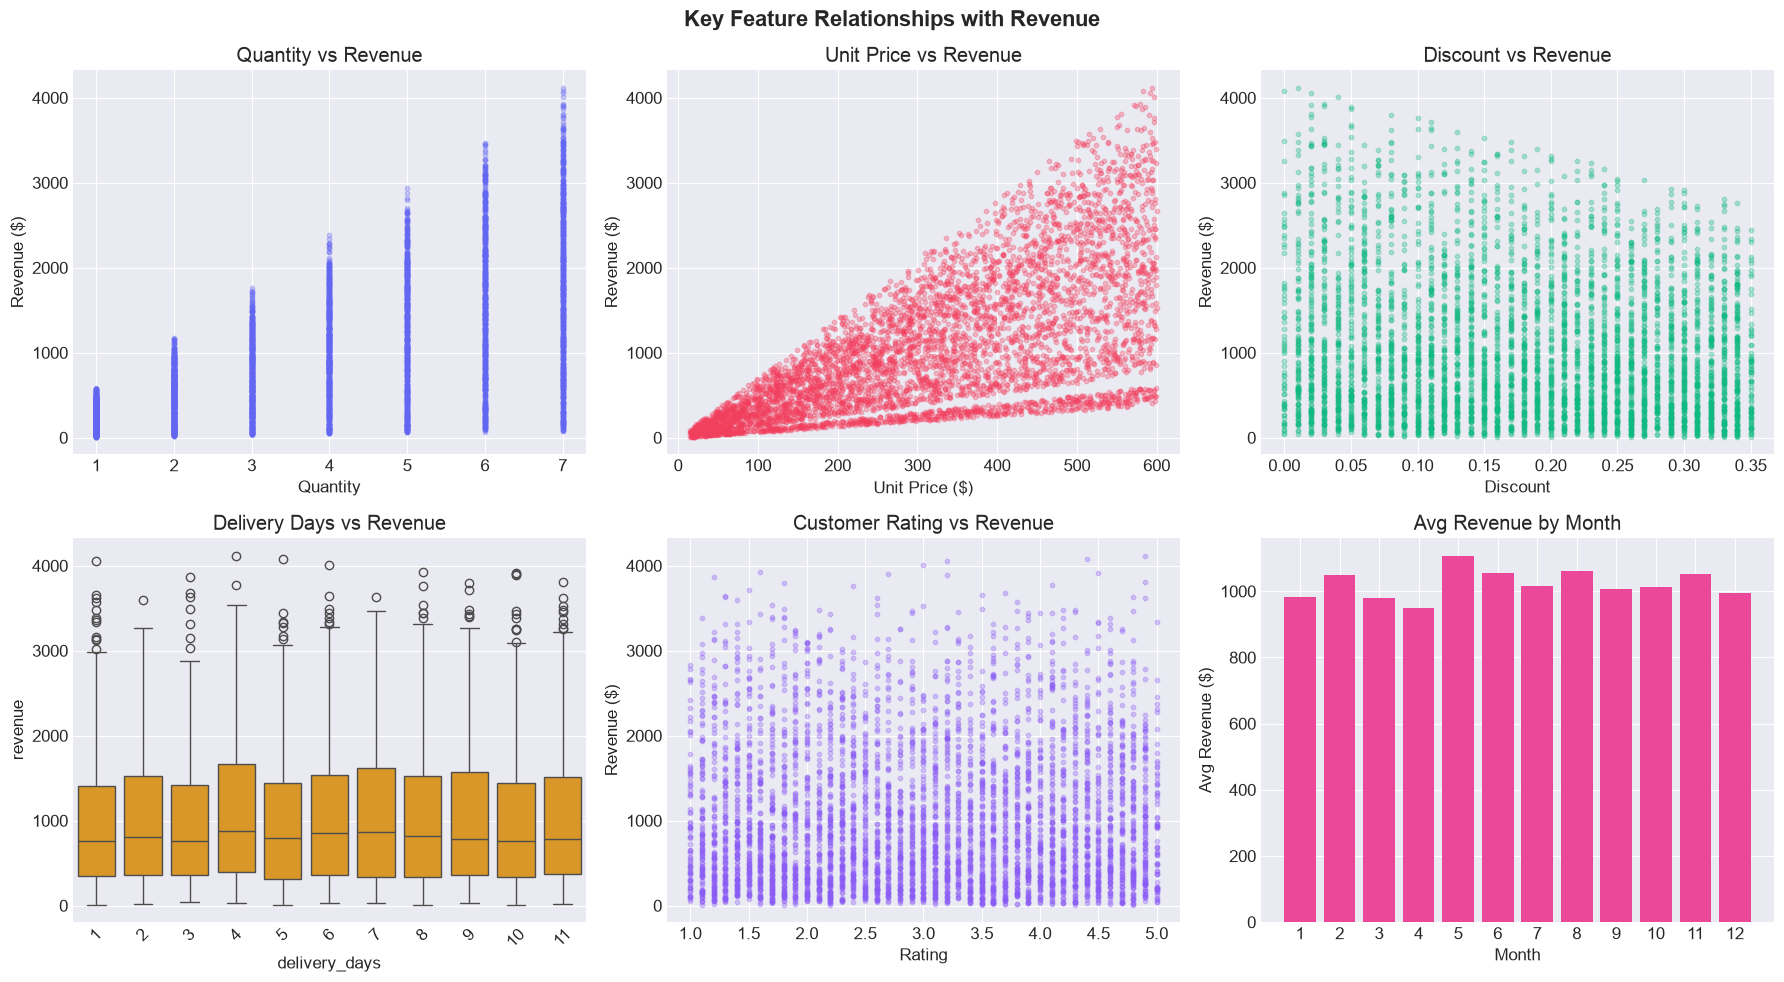

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Feature Relationships with Revenue', fontsize=16, fontweight='bold')

# Quantity vs Revenue
axes[0, 0].scatter(df['quantity'], df['revenue'], alpha=0.3, color='#6366f1', s=10)
axes[0, 0].set_title('Quantity vs Revenue')
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Revenue ($)')

# Unit Price vs Revenue
axes[0, 1].scatter(df['unit_price'], df['revenue'], alpha=0.3, color='#f43f5e', s=10)
axes[0, 1].set_title('Unit Price vs Revenue')
axes[0, 1].set_xlabel('Unit Price ($)')
axes[0, 1].set_ylabel('Revenue ($)')

# Discount vs Revenue
axes[0, 2].scatter(df['discount'], df['revenue'], alpha=0.3, color='#10b981', s=10)
axes[0, 2].set_title('Discount vs Revenue')
axes[0, 2].set_xlabel('Discount')
axes[0, 2].set_ylabel('Revenue ($)')

# Delivery Days vs Revenue
sns.boxplot(data=df, x='delivery_days', y='revenue', color='#f59e0b', ax=axes[1, 0])
axes[1, 0].set_title('Delivery Days vs Revenue')
axes[1, 0].tick_params(axis='x', rotation=45)

# Customer Rating vs Revenue
axes[1, 1].scatter(df['customer_rating'], df['revenue'], alpha=0.3, color='#8b5cf6', s=10)
axes[1, 1].set_title('Customer Rating vs Revenue')
axes[1, 1].set_xlabel('Rating')
axes[1, 1].set_ylabel('Revenue ($)')

# Monthly average revenue
monthly_rev = df.groupby('order_month')['revenue'].mean()
axes[1, 2].bar(monthly_rev.index, monthly_rev.values, color='#ec4899')
axes[1, 2].set_title('Avg Revenue by Month')
axes[1, 2].set_xlabel('Month')
axes[1, 2].set_ylabel('Avg Revenue ($)')
axes[1, 2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

### 4.7 Interactive Plotly Visualizations

In [14]:
# Interactive scatter: Quantity vs Revenue colored by Category
fig = px.scatter(df, x='unit_price', y='revenue', color='product_category',
                 size='quantity', hover_data=['discount', 'region', 'payment_method'],
                 title='Unit Price vs Revenue (by Category & Quantity)',
                 opacity=0.6,
                 color_discrete_sequence=['#667eea', '#f43f5e', '#10b981', '#f59e0b'])
fig.update_layout(height=500)
fig.show()

In [15]:
# Sunburst chart: Category > Region > Payment
fig = px.sunburst(df, path=['product_category', 'region', 'payment_method'],
                  values='revenue', title='Revenue Breakdown: Category → Region → Payment',
                  color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(height=600)
fig.show()

---

## 5. 🤖 Machine Learning - Revenue Prediction

### 5.1 Feature Preparation

In [16]:
# Select features for modeling
feature_cols = ['quantity', 'unit_price', 'discount', 'delivery_days',
                'customer_rating', 'order_month', 'order_quarter', 'order_day_of_week']

# Encode categorical variables
label_encoders = {}
categorical_cols = ['product_category', 'region', 'payment_method']

for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    feature_cols.append(f'{col}_encoded')
    print(f'{col} encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nTotal features: {len(feature_cols)}')
print(f'Features: {feature_cols}')

product_category encoding: {'Beauty': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2), 'Home': np.int64(3)}
region encoding: {'East': np.int64(0), 'North': np.int64(1), 'South': np.int64(2), 'West': np.int64(3)}
payment_method encoding: {'COD': np.int64(0), 'Card': np.int64(1), 'Wallet': np.int64(2)}

Total features: 11
Features: ['quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating', 'order_month', 'order_quarter', 'order_day_of_week', 'product_category_encoded', 'region_encoded', 'payment_method_encoded']


In [17]:
# Prepare X and y
X = df[feature_cols]
y = df['revenue']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: 4000 samples
Testing set:  1000 samples


### 5.2 Model Training & Evaluation

In [18]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=15,
        min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=5,
        learning_rate=0.1, random_state=42
    )
}

results = {}

for name, model in models.items():
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'{"="*50}')
    
    # Use scaled data for Linear Regression, raw for tree-based
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model': model, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
        'CV_Mean': cv_scores.mean(), 'CV_Std': cv_scores.std(),
        'predictions': y_pred
    }
    
    print(f'  MAE:  ${mae:,.2f}')
    print(f'  RMSE: ${rmse:,.2f}')
    print(f'  R²:   {r2:.4f}')
    print(f'  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


Training: Linear Regression
  MAE:  $220.20
  RMSE: $296.35
  R²:   0.8697
  CV R² (5-fold): 0.8674 ± 0.0055

Training: Random Forest
  MAE:  $20.07
  RMSE: $30.23
  R²:   0.9986
  CV R² (5-fold): 0.9981 ± 0.0001

Training: Gradient Boosting
  MAE:  $14.70
  RMSE: $20.46
  R²:   0.9994
  CV R² (5-fold): 0.9992 ± 0.0001


### 5.3 Model Comparison

In [19]:
# Comparison DataFrame
comparison_df = pd.DataFrame({
    name: {'MAE ($)': f"${r['MAE']:,.2f}", 'RMSE ($)': f"${r['RMSE']:,.2f}",
           'R² Score': f"{r['R2']:.4f}", 'CV R² (mean)': f"{r['CV_Mean']:.4f}"}
    for name, r in results.items()
}).T

print('\n🏆 MODEL COMPARISON')
print('=' * 60)
comparison_df


🏆 MODEL COMPARISON


,MAE ($),RMSE ($),R² Score,CV R² (mean)
Linear Regression,$220.20,$296.35,0.8697,0.8674
Random Forest,$20.07,$30.23,0.9986,0.9981
Gradient Boosting,$14.70,$20.46,0.9994,0.9992


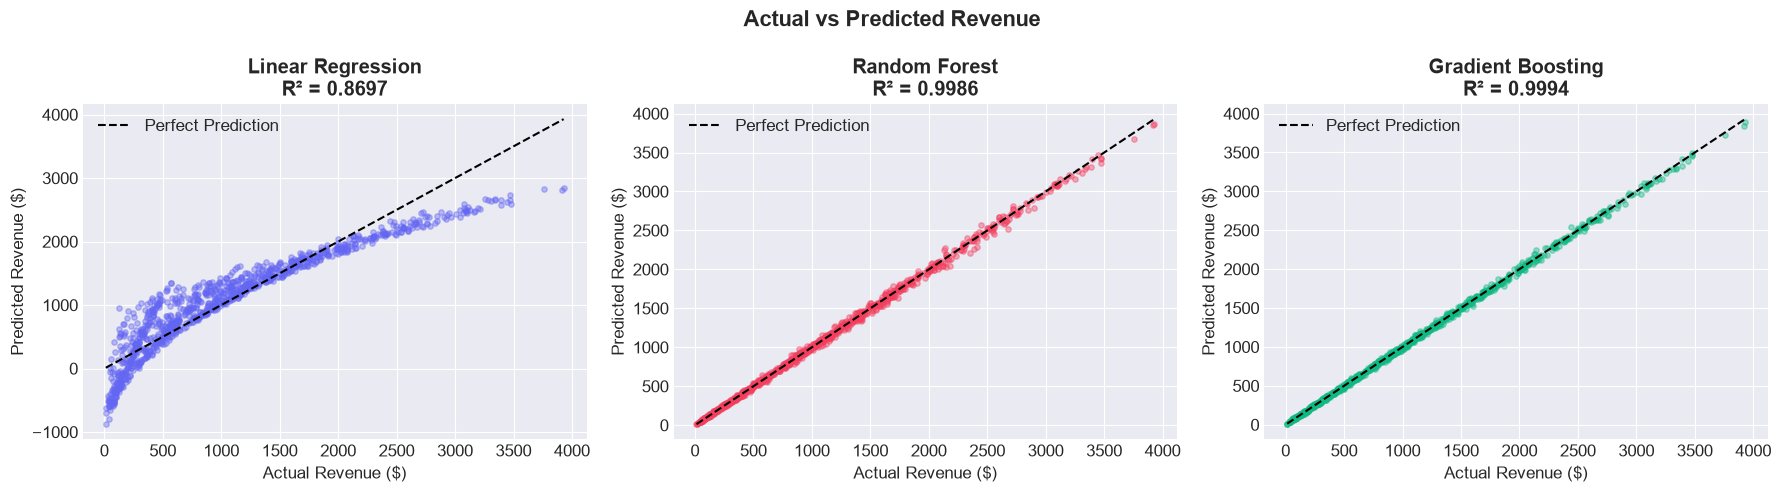

In [20]:
# Actual vs Predicted plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Actual vs Predicted Revenue', fontsize=16, fontweight='bold')
colors = ['#6366f1', '#f43f5e', '#10b981']

for idx, (name, result) in enumerate(results.items()):
    axes[idx].scatter(y_test, result['predictions'], alpha=0.4, color=colors[idx], s=15)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                   'k--', linewidth=1.5, label='Perfect Prediction')
    axes[idx].set_title(f'{name}\nR² = {result["R2"]:.4f}', fontweight='bold')
    axes[idx].set_xlabel('Actual Revenue ($)')
    axes[idx].set_ylabel('Predicted Revenue ($)')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [21]:
# Find the best model
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_result = results[best_model_name]
print(f'🏆 Best Model: {best_model_name}')
print(f'   R² Score: {best_result["R2"]:.4f}')
print(f'   MAE:      ${best_result["MAE"]:,.2f}')
print(f'   RMSE:     ${best_result["RMSE"]:,.2f}')

🏆 Best Model: Gradient Boosting
   R² Score: 0.9994
   MAE:      $14.70
   RMSE:     $20.46


### 5.4 Feature Importance

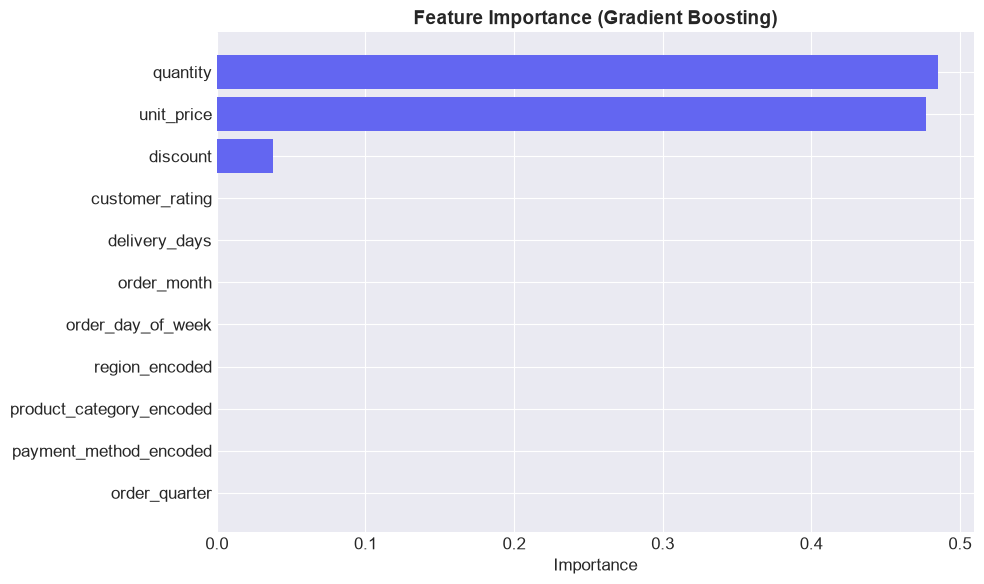


Top 5 Most Important Features:
  • quantity: 0.4852
  • unit_price: 0.4770
  • discount: 0.0377
  • customer_rating: 0.0000
  • delivery_days: 0.0000


In [22]:
# Feature importance from best model (if tree-based)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    best_model = best_result['model']
    fi_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi_df['Feature'], fi_df['Importance'], color='#6366f1')
    ax.set_title(f'Feature Importance ({best_model_name})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print('\nTop 5 Most Important Features:')
    for _, row in fi_df.tail(5).iloc[::-1].iterrows():
        print(f'  • {row["Feature"]}: {row["Importance"]:.4f}')

### 5.5 Residual Analysis

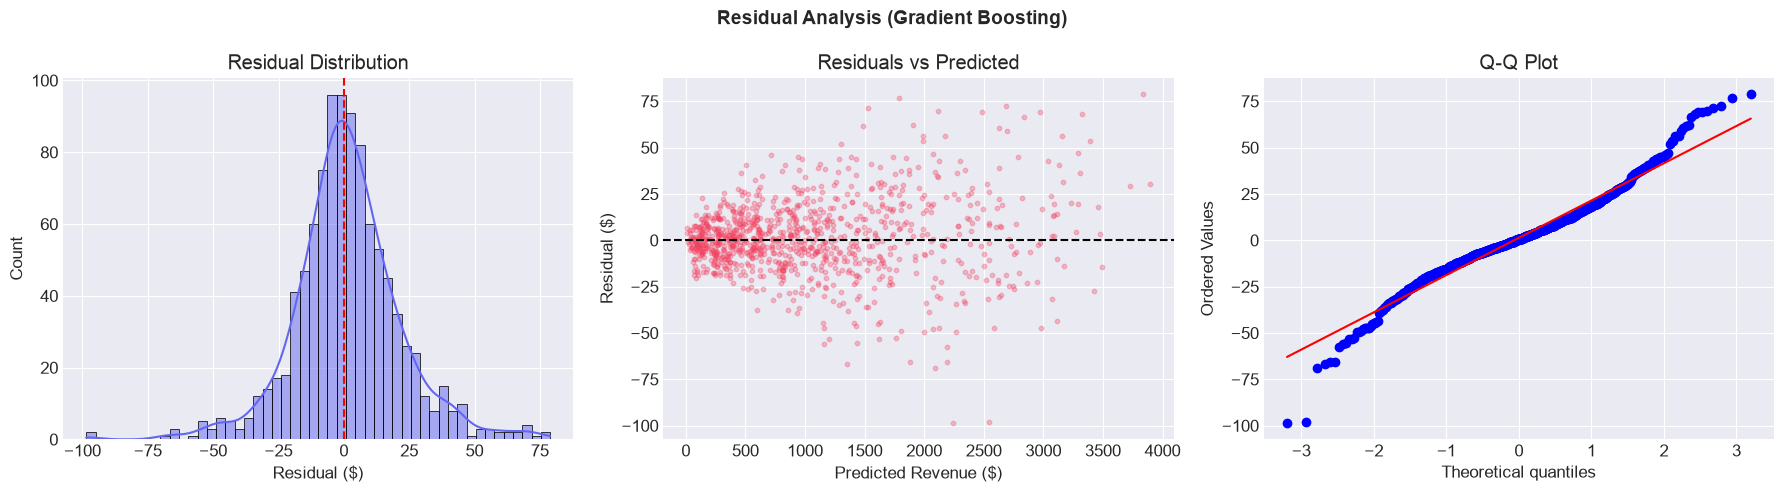

Mean Residual: $1.37
Std Residual:  $20.43


In [23]:
# Residual analysis for best model
residuals = y_test - best_result['predictions']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Residual Analysis ({best_model_name})', fontsize=14, fontweight='bold')

# Residual distribution
sns.histplot(residuals, bins=50, kde=True, color='#6366f1', ax=axes[0])
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual ($)')
axes[0].axvline(0, color='red', linestyle='--')

# Residuals vs Predicted
axes[1].scatter(best_result['predictions'], residuals, alpha=0.3, color='#f43f5e', s=10)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Revenue ($)')
axes[1].set_ylabel('Residual ($)')

# QQ plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f'Mean Residual: ${residuals.mean():.2f}')
print(f'Std Residual:  ${residuals.std():.2f}')

---

## 6. 💾 Save Model & Artifacts

In [24]:
# Save the best model
best_model_obj = best_result['model']
joblib.dump(best_model_obj, 'revenue_model.pkl')
print(f'✅ Best model ({best_model_name}) saved to revenue_model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print('✅ Scaler saved to scaler.pkl')

# Save label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')
print('✅ Label encoders saved to label_encoders.pkl')

# Save feature columns
joblib.dump(feature_cols, 'feature_columns.pkl')
print('✅ Feature columns saved to feature_columns.pkl')

# Save model metadata
model_metadata = {
    'best_model_name': best_model_name,
    'features': feature_cols,
    'categorical_columns': categorical_cols,
    'metrics': {
        'MAE': best_result['MAE'],
        'RMSE': best_result['RMSE'],
        'R2': best_result['R2'],
        'CV_R2_mean': best_result['CV_Mean'],
        'CV_R2_std': best_result['CV_Std']
    },
    'all_model_results': {
        name: {'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R2': r['R2']}
        for name, r in results.items()
    },
    'category_values': df['product_category'].unique().tolist(),
    'region_values': df['region'].unique().tolist(),
    'payment_values': df['payment_method'].unique().tolist(),
    'data_stats': {
        'total_records': len(df),
        'train_size': len(X_train),
        'test_size': len(X_test),
        'revenue_mean': float(df['revenue'].mean()),
        'revenue_std': float(df['revenue'].std()),
    }
}
joblib.dump(model_metadata, 'model_metadata.pkl')
print('✅ Model metadata saved to model_metadata.pkl')

# Save processed data
df.to_csv('processed_data.csv', index=False)
print('✅ Processed dataset saved to processed_data.csv')

✅ Best model (Gradient Boosting) saved to revenue_model.pkl
✅ Scaler saved to scaler.pkl
✅ Label encoders saved to label_encoders.pkl
✅ Feature columns saved to feature_columns.pkl
✅ Model metadata saved to model_metadata.pkl
✅ Processed dataset saved to processed_data.csv


In [25]:
# Quick test: Load and verify saved model
loaded_model = joblib.load('revenue_model.pkl')
test_pred = loaded_model.predict(X_test[:5])

print('\n🔍 Model Verification:')
print('Sample predictions from loaded model:')
for actual, predicted in zip(y_test[:5].values, test_pred):
    print(f'  Actual: ${actual:,.2f} → Predicted: ${predicted:,.2f}')

print(f'\n✅ Model verified successfully!')
print(f'\n🚀 To run the Streamlit app, use:')
print(f'   streamlit run app.py')


🔍 Model Verification:
Sample predictions from loaded model:
  Actual: $2,188.36 → Predicted: $2,187.43
  Actual: $2,340.93 → Predicted: $2,297.88
  Actual: $2,762.76 → Predicted: $2,768.84
  Actual: $1,758.37 → Predicted: $1,741.65
  Actual: $2,597.89 → Predicted: $2,628.30

✅ Model verified successfully!

🚀 To run the Streamlit app, use:
   streamlit run app.py


---

## ✅ Summary

| Step | Status |
|------|--------|
| Data Loading | ✅ 5,000 records loaded |
| Data Cleaning | ✅ No missing values, features engineered |
| EDA | ✅ Revenue, category, region, correlations analyzed |
| Model Training | ✅ 3 models trained and evaluated |
| Model Saved | ✅ Best model saved to `revenue_model.pkl` |
| Streamlit App | ✅ Ready at `app.py` |

**Next Step:** Run `streamlit run app.py` to launch the interactive prediction dashboard!